<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [8]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




In [3]:
## Write your code here
import numpy as np

# 1. Define the mapping of age ranges to numerical midpoints
age_midpoint_map = {
    'Under 18 years old': 8.5,
    '18-24 years old': 21.0,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 67.5,
    'Prefer not to say': np.nan  # Set to NaN first to calculate a clean mean
}

# 2. Apply the mapping to create the new numeric column
# Assuming 'df_combined' is your DataFrame
df['Age_Midpoint'] = df['Age'].replace(age_midpoint_map)

# 3. Ensure the column is strictly numeric
df['Age_Midpoint'] = pd.to_numeric(df['Age_Midpoint'], errors='coerce')

# 4. Optional: Impute missing values with the mean
imputation_mean = df['Age_Midpoint'].mean()
df['Age_Midpoint'] = df['Age_Midpoint'].fillna(imputation_mean)

print(f"Imputation Mean: {imputation_mean:.2f}")

Imputation Mean: 32.68


/tmp/ipykernel_338/3242891794.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Age_Midpoint'] = df['Age'].replace(age_midpoint_map)


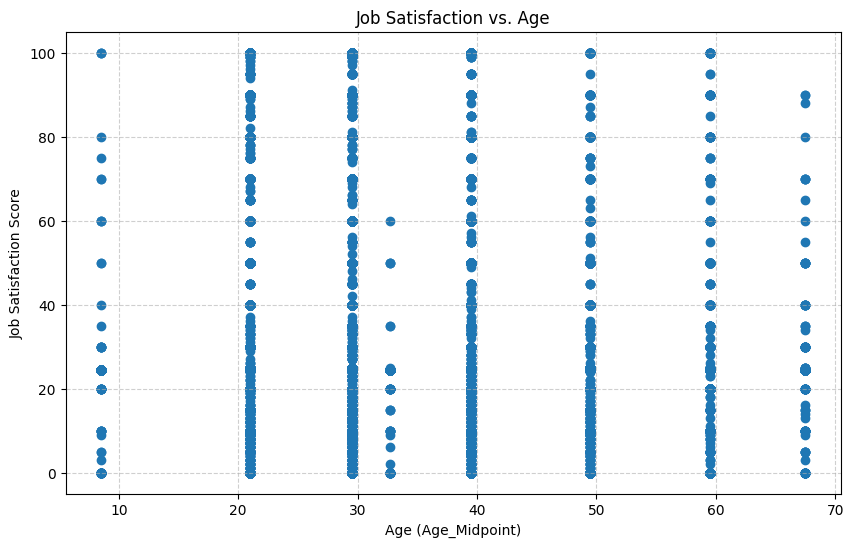

In [4]:
df['JobSatPoints_6'] = df['JobSatPoints_6'].fillna(df['JobSatPoints_6'].mean())

plt.figure(figsize = (10,6))
plt.scatter(x = df['Age_Midpoint'], y = df['JobSatPoints_6'])
plt.title('Job Satisfaction vs. Age')
plt.xlabel('Age (Age_Midpoint)')
plt.ylabel('Job Satisfaction Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


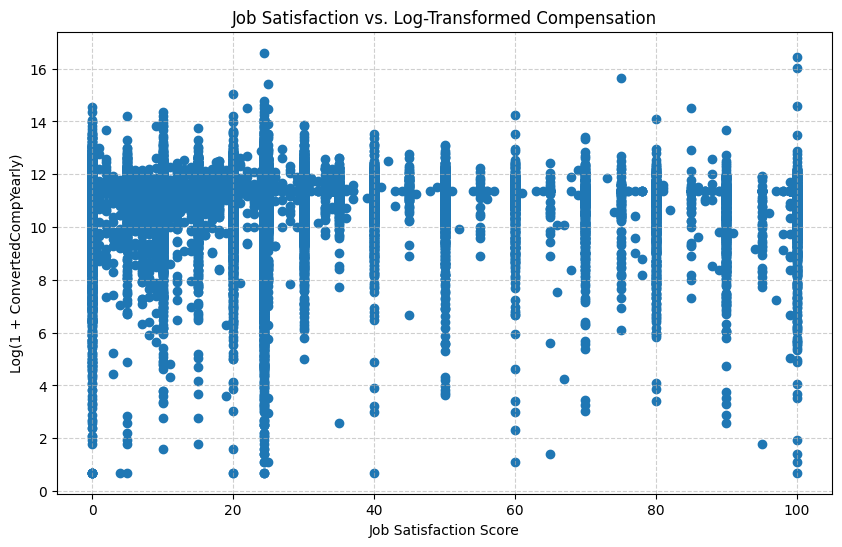

In [5]:
## Write your code here
import numpy as np
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(df['ConvertedCompYearly'].mean())

plt.figure(figsize = (10,6))

plt.scatter(x = df['JobSatPoints_6'], y  = np.log1p(df['ConvertedCompYearly']));
plt.title('Job Satisfaction vs. Log-Transformed Compensation')
plt.xlabel(f'Job Satisfaction Score')
plt.ylabel('Log(1 + ConvertedCompYearly)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


<Axes: xlabel='Age_Midpoint', ylabel='JobSatPoints_6'>

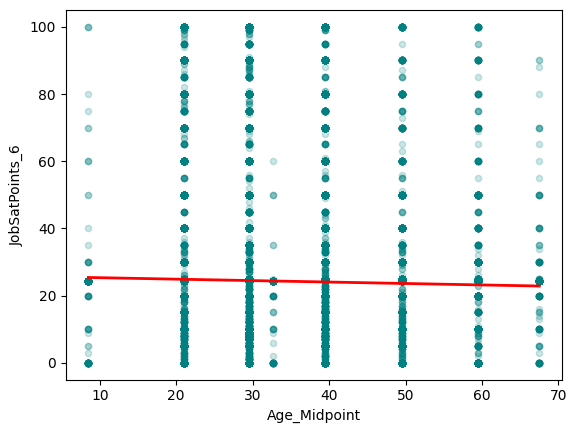

In [10]:
## Write your code here
import seaborn as sns
sns.regplot(
    x='Age_Midpoint', 
    y='JobSatPoints_6', 
    data=df,
    scatter_kws={'alpha':0.2, 's':20, 'color':'teal'}, # Style for the points
    line_kws={'color':'red', 'lw':2}                  # Style for the trend line
)

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


Text(0, 0.5, 'Years of Professional Coding Experience')

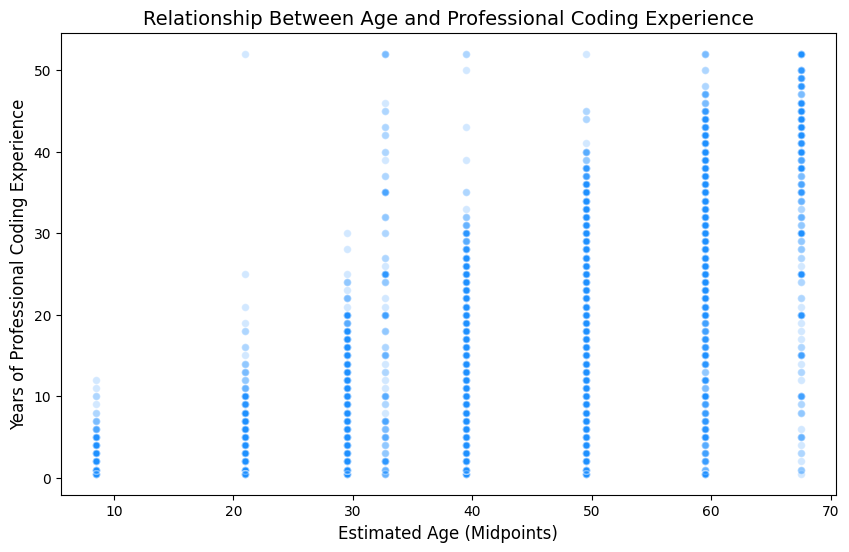

In [15]:
## Write your code here
yearscodepro_map = {
    'Less than 1 year': 0.5,
    'More than 50 years': 52.0
}

# Map the special strings, then convert the whole column to numeric
df['YearsCodePro_Numeric'] = df['YearsCodePro'].replace(yearscodepro_map)
df['YearsCodePro_Numeric'] = pd.to_numeric(df['YearsCodePro_Numeric'], errors='coerce')

plot_data = df.dropna(subset=['Age_Midpoint', 'YearsCodePro_Numeric'])

# 5. Generate the Scatter Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    x=plot_data['Age_Midpoint'], 
    y=plot_data['YearsCodePro_Numeric'],
    alpha=0.2,      # Transparency to handle overlapping points
    color='dodgerblue',
    edgecolors='w', # White border for dots to make them pop
    s=30            # Size of the dots
)

# Add Labels and Title
plt.title('Relationship Between Age and Professional Coding Experience', fontsize=14)
plt.xlabel('Estimated Age (Midpoints)', fontsize=12)
plt.ylabel('Years of Professional Coding Experience', fontsize=12)


### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


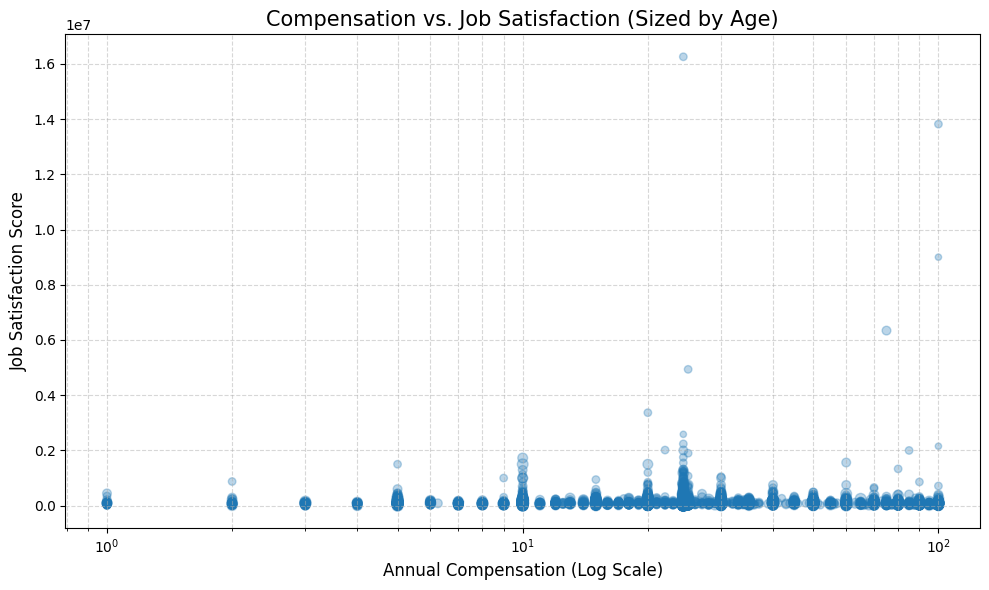

In [25]:
## Write your code here
plt.figure(figsize = (10,6))

plt.scatter(
    x = df['JobSatPoints_6'],
    y = df['ConvertedCompYearly'],
    s=df['Age_Midpoint'],  # Scaling factor to make bubbles visible
    alpha=0.3,                       # High transparency to see through density
)

plt.title('Compensation vs. Job Satisfaction (Sized by Age)', fontsize=15)
plt.xlabel('Annual Compensation (Log Scale)', fontsize=12)
plt.ylabel('Job Satisfaction Score', fontsize=12)

# Apply log scale to X-axis to handle salary outliers
plt.xscale('log') 

plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


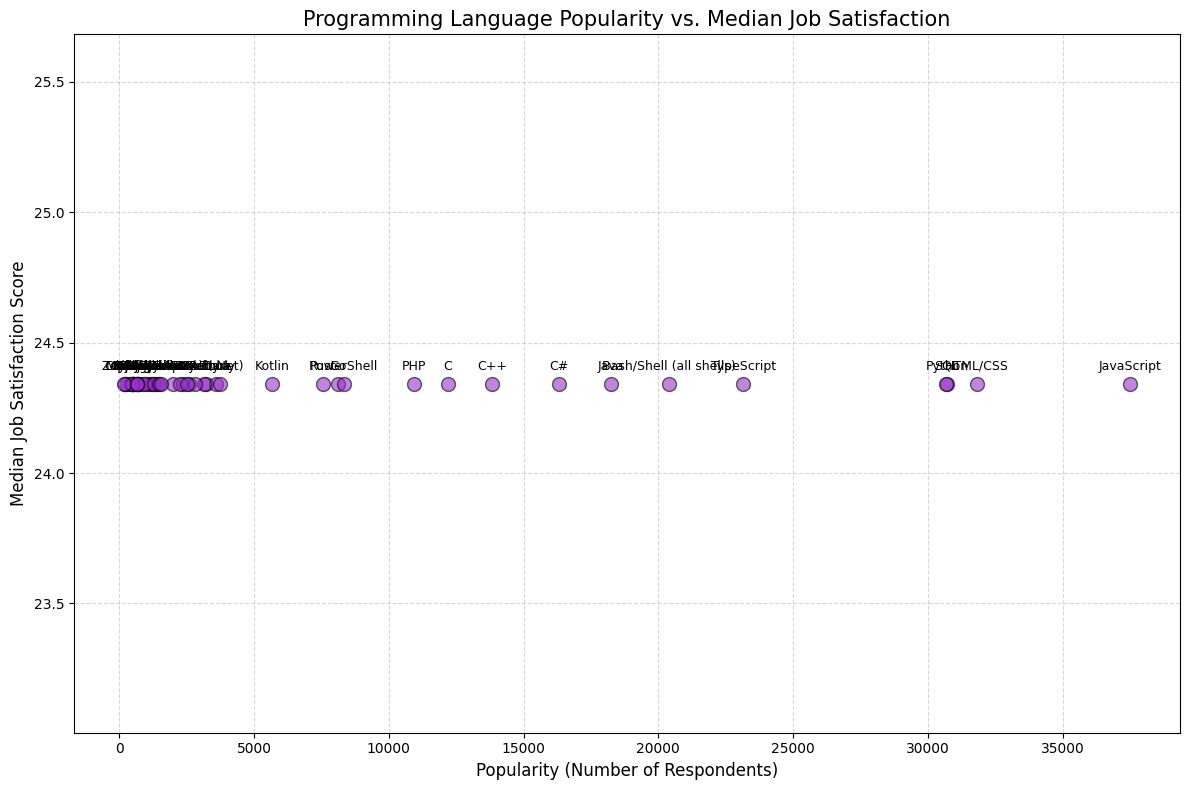

Top 10 Languages by Median Job Satisfaction:
                  Language  count     median
0                      Ada    542  24.343232
1                     Apex    502  24.343232
2                 Assembly   3233  24.343232
3  Bash/Shell (all shells)  20412  24.343232
4                        C  12184  24.343232
5                       C#  16318  24.343232
6                      C++  13827  24.343232
7                  Clojure    737  24.343232
8                    Cobol    413  24.343232
9                  Crystal    253  24.343232


In [27]:
## Write your code here
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
df_clean = df.dropna(subset=['LanguageHaveWorkedWith', 'JobSatPoints_6']).copy()

# 2. Split and Explode the Languages
# This turns "Python;SQL" into two separate rows for the same satisfaction score
df_clean['Language'] = df_clean['LanguageHaveWorkedWith'].str.split(';')
df_exploded = df_clean.explode('Language')

# 3. Aggregate Data per Language
# We want the count (Popularity) and the Median Satisfaction
lang_stats = df_exploded.groupby('Language')['JobSatPoints_6'].agg(['count', 'median']).reset_index()

# 4. Filter for Significance
# Removing languages with very few responses to avoid outliers
min_responses = 50 
lang_stats = lang_stats[lang_stats['count'] >= min_responses]

# 5. Create the Scatter Plot
plt.figure(figsize=(12, 8))

# X-axis: Popularity (Count), Y-axis: Satisfaction (Median)
plt.scatter(
    x=lang_stats['count'], 
    y=lang_stats['median'],
    alpha=0.6,
    color='darkorchid',
    s=100,      # Fixed size for points
    edgecolors='black'
)

# 6. Add Labels to points
# This helps identify which dot belongs to which language
for i, row in lang_stats.iterrows():
    plt.annotate(
        row['Language'], 
        (row['count'], row['median']),
        textcoords="offset points", 
        xytext=(0,10), 
        ha='center',
        fontsize=9
    )

# 7. Styling
plt.title('Programming Language Popularity vs. Median Job Satisfaction', fontsize=15)
plt.xlabel('Popularity (Number of Respondents)', fontsize=12)
plt.ylabel('Median Job Satisfaction Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Use a log scale for X if the popularity difference is massive
# plt.xscale('log') 

plt.tight_layout()
plt.show()

# Print the top 10 most satisfying languages
print("Top 10 Languages by Median Job Satisfaction:")
print(lang_stats.sort_values(by='median', ascending=False).head(10))

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


/tmp/ipykernel_338/2345738502.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


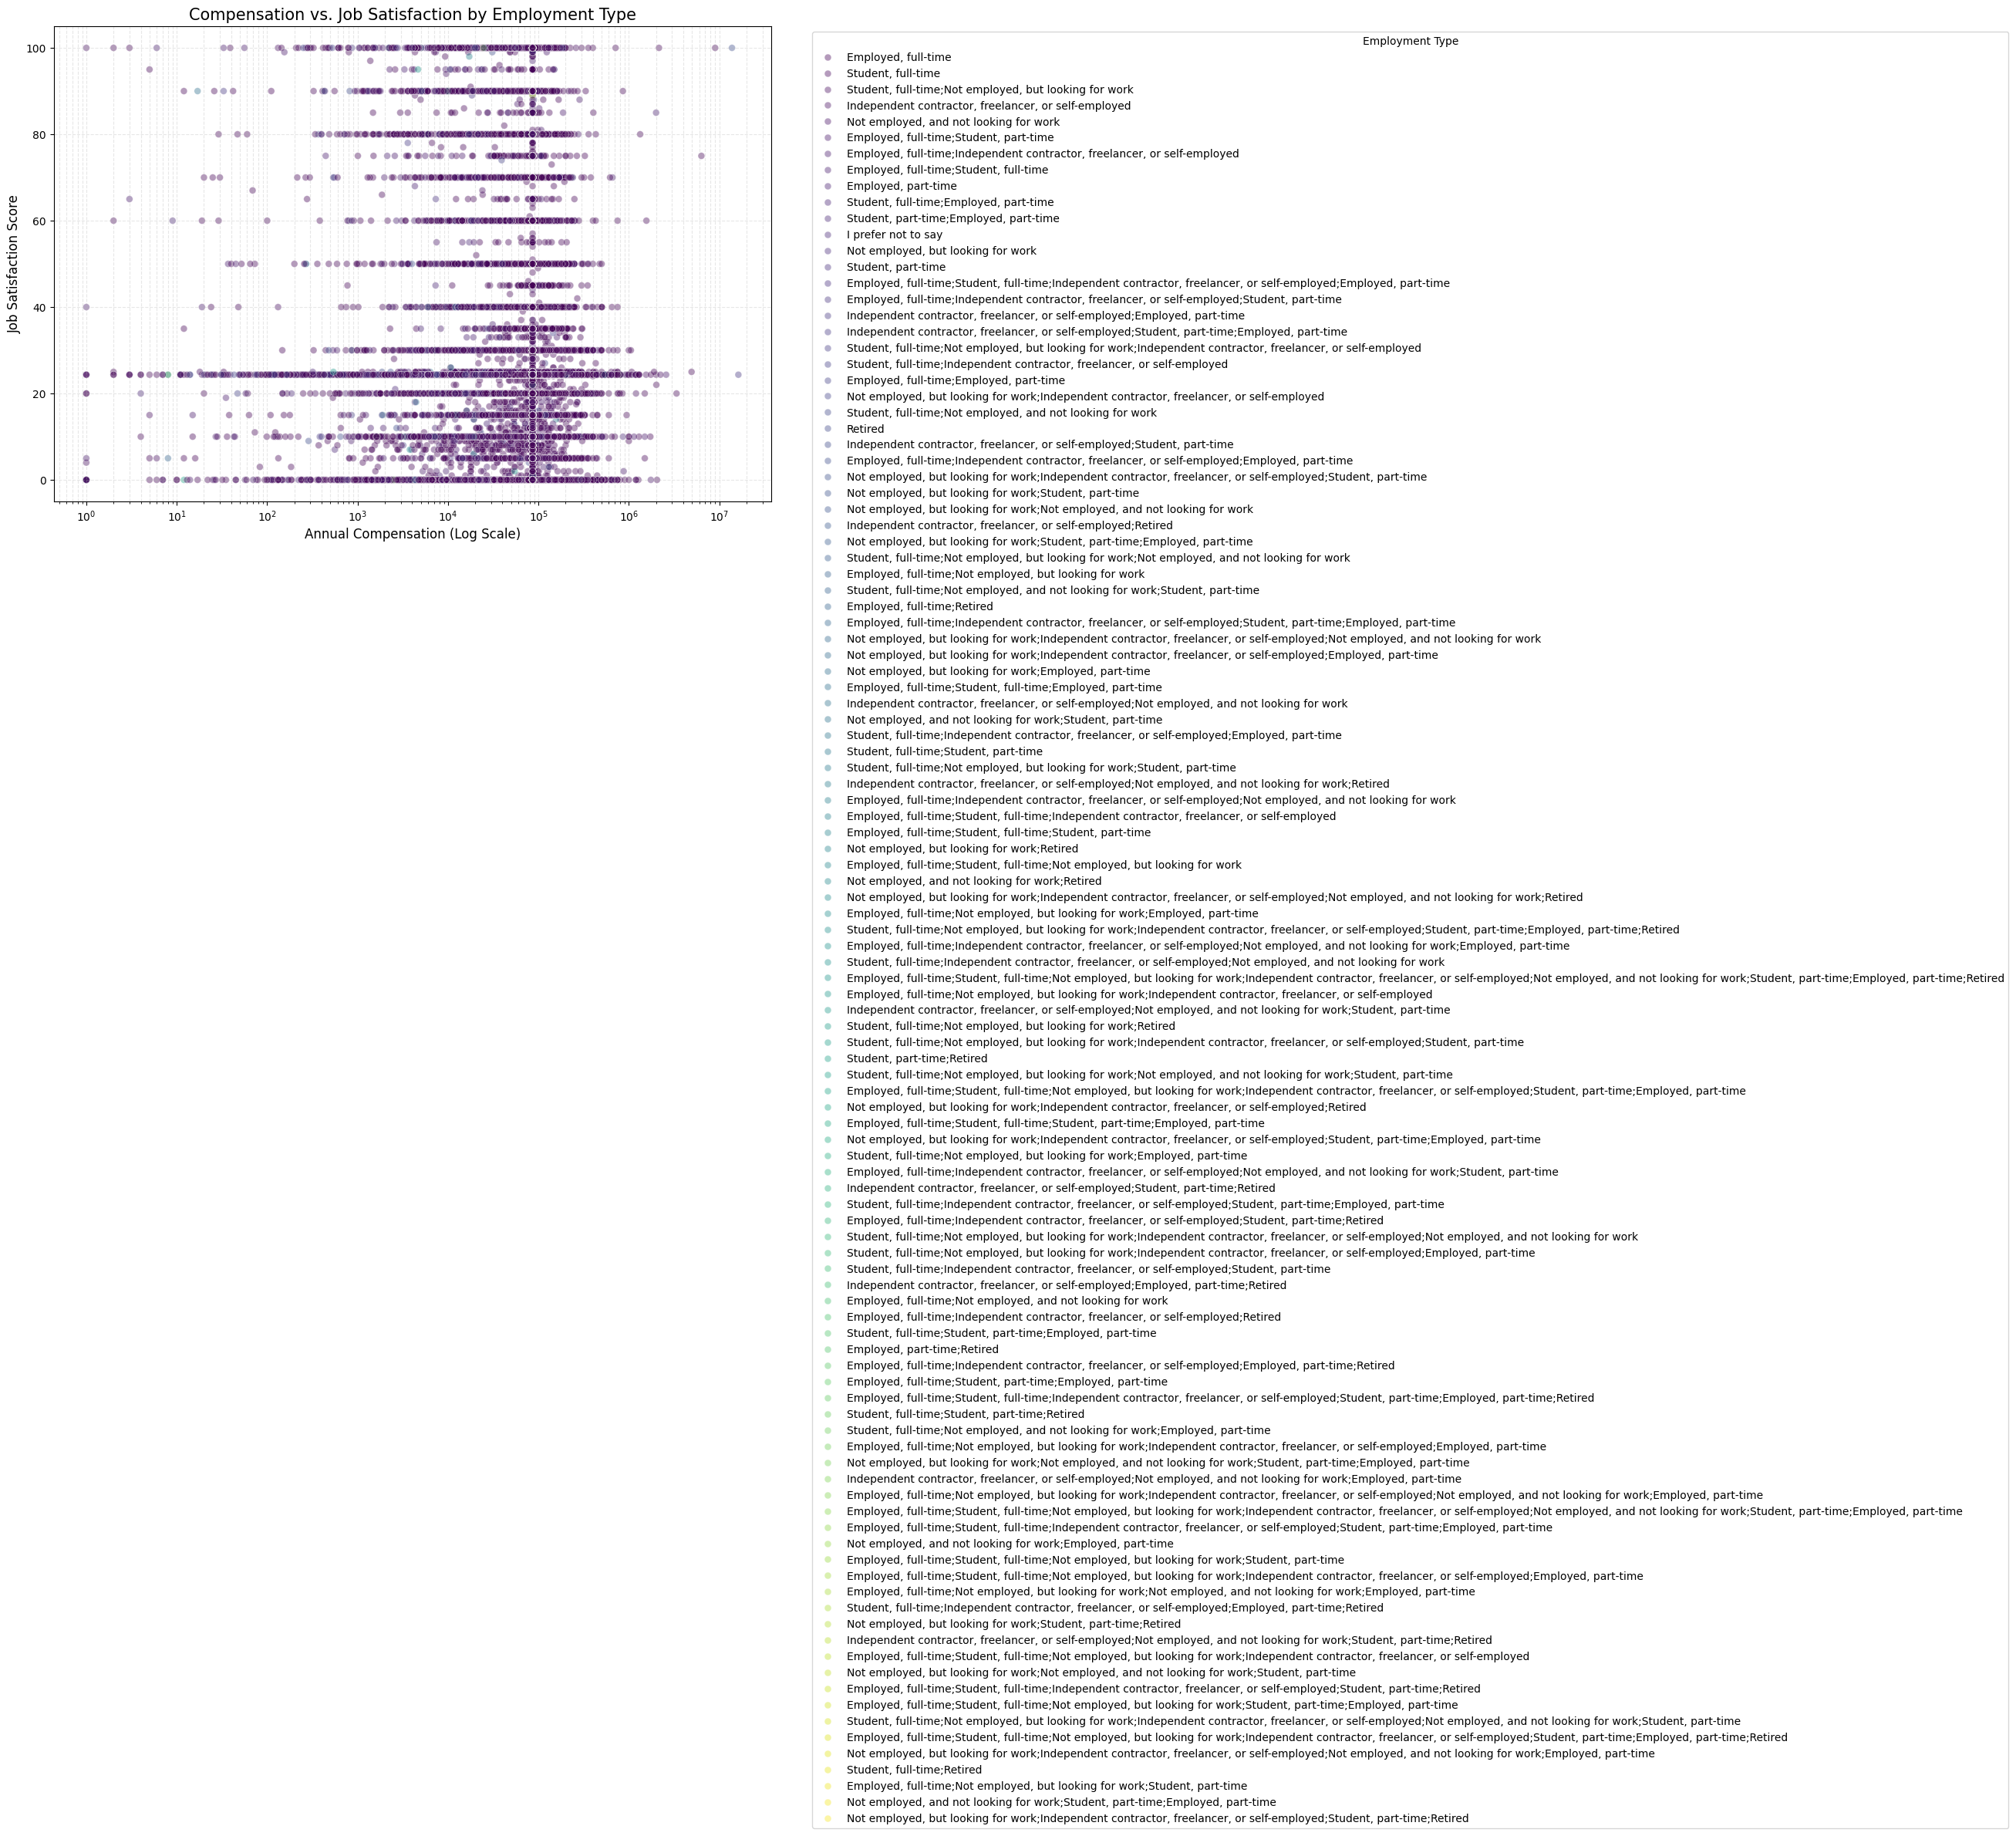

In [28]:
## Write your code here
# 1. Clean Numeric Data
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# 2. Select columns and drop NaNs
# We focus on rows that have all three required pieces of information
plot_data = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6', 'Employment']).copy()

# 3. Create the Scatter Plot
plt.figure(figsize=(12, 8))

# Using Seaborn's scatterplot to automatically handle the legend and color mapping
sns.scatterplot(
    data=plot_data,
    x='ConvertedCompYearly',
    y='JobSatPoints_6',
    hue='Employment',      # Categorize by color
    alpha=0.4,             # Transparency to handle dense areas
    palette='viridis',     # Color scheme
    s=40                   # Size of points
)

# 4. Apply Log Scale to Compensation
# This spreads out the salary data so the relationship is visible
plt.xscale('log')

# 5. Styling and Labels
plt.title('Compensation vs. Job Satisfaction by Employment Type', fontsize=15)
plt.xlabel('Annual Compensation (Log Scale)', fontsize=12)
plt.ylabel('Job Satisfaction Score', fontsize=12)

# Move the legend outside the plot because employment strings can be long
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, which="both", linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


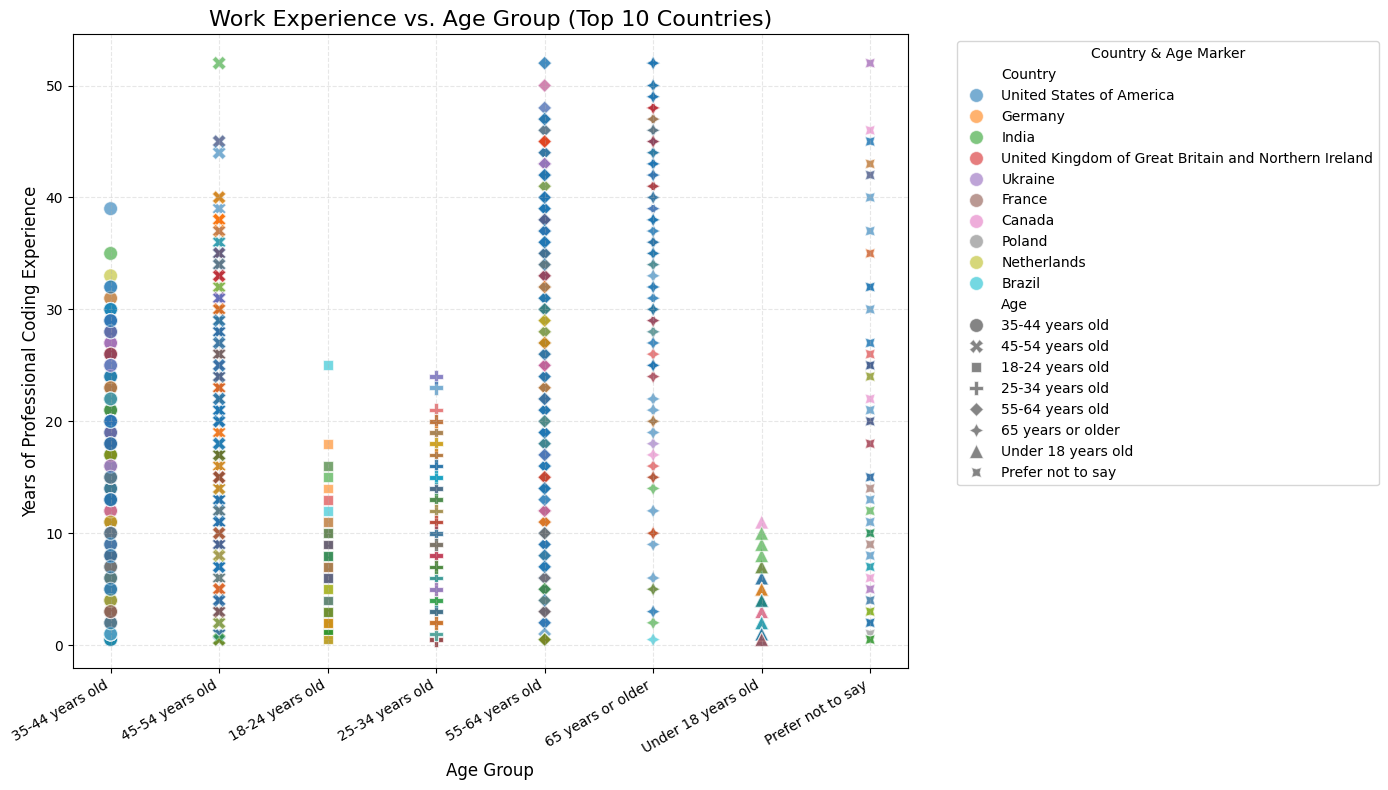

Scatter plot generated comparing experience across age groups for the top 10 countries.


In [31]:
## Write your code here

# 1. Clean Professional Experience Data (YearsCodePro)
# Map qualitative strings to numerical values and convert to float
experience_map = {
    'Less than 1 year': 0.5, 
    'More than 50 years': 52.0
}
df['YearsCodePro_Numeric'] = df['YearsCodePro'].replace(experience_map)
df['YearsCodePro_Numeric'] = pd.to_numeric(df['YearsCodePro_Numeric'], errors='coerce')

# 2. Filter for Top Countries to ensure plot readability
# Plotting dozens of countries would make the hue legend unusable
top_n = 10
top_countries = df['Country'].value_counts().nlargest(top_n).index
plot_data = df[df['Country'].isin(top_countries)].copy()

# Drop rows with missing values in our target columns
plot_data = plot_data.dropna(subset=['YearsCodePro_Numeric', 'Age', 'Country'])

# 3. Set order for Age groups to ensure the X-axis is chronological
age_order = [
    'Under 18 years old', 
    '18-24 years old', 
    '25-34 years old', 
    '35-44 years old', 
    '45-54 years old', 
    '55-64 years old', 
    '65 years or older'
]

# 4. Create the Scatter Plot
plt.figure(figsize=(14, 8))

# Using hue for Country and style (markers) for Age groups
sns.scatterplot(
    data=plot_data,
    x='Age',
    y='YearsCodePro_Numeric',
    hue='Country',            # Color by Country
    style='Age',              # Different markers for different Age Groups
    palette='tab10',          # Clear distinct colors
    s=100,                    # Larger points for visibility
    alpha=0.6,                # Transparency to see overlapping data
    hue_order=top_countries,
    #x_order=age_order
)

# 5. Styling and Labels
plt.title(f'Work Experience vs. Age Group (Top {top_n} Countries)', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Years of Professional Coding Experience', fontsize=12)

# Rotate X-axis labels to prevent overlapping
plt.xticks(rotation=30, ha='right')

# Move the legend outside the plot area
plt.legend(title='Country & Age Marker', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Scatter plot generated comparing experience across age groups for the top {top_n} countries.")

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
